<a href="https://colab.research.google.com/github/emm-gl/ClassificadorCancerEsofago/blob/master/Notebooks/PerceptronClasificadorCancerEs%C3%B3fago.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Tejidos Cancerígenos

Septiembre de 2026

Este notebook muestra el uso del hiperplano para un problema de clasificación de dos categorias:
* Tejido sano -> Clase 0
* Tejido cancerigeno -> Clase 1


Dataframe de 5063 imágenes supervisadas

<h2> Clasificador de tejido sano y tejido cancerígeno en imágenes microscópicas del esófago

![image.png](https://drive.google.com/uc?id=1K_j4CnOJeOmiROBiFwEW1M-kJkizrMk7)

## Paso 1. Cargar librerías y módulos requerdidos

In [2]:
import random        # Módulo para aleatorizar.
import pickle        # Módulo para respaldar objetos de pyhton como cadenas de bytes
                     # (serialización de objetos).

import numpy as np   # Biblioteca para manejar matrices y operaciones de matrices
import pandas as pd  # Biblioteca para manejar tablas de datos.

# Funciones de la biblioteca Scikit-image para leer y mostrar una una imagen.
from skimage.io import imread

# Sklearn (Scikit-learn) es la  principal biblioteca para machine learning.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron

# Bibliotecas para gráficar y visualizar.
import matplotlib.pyplot as plt
import seaborn as sns

## Paso 2. Lectura de datos.

### 2.1 Lectura de etiquetas (y)

In [13]:
# Leemos los datos. Se tienen la etiqueta de cada imágen en un archivo CSV con columna del nombre de la imagen y con la etiqueta de cada imagen.

datos = pd.read_csv("https://raw.githubusercontent.com/AnIsAsPe/ClassificadorCancerEsofago/master/Datos/ClasesImagenes.csv", usecols=[1,2])

# Muestra los primeros cinco registros.
datos.head()

,image_filename,class_number
0,im_4_0.png,0
1,im_21_0.png,0
2,im_9_0.png,0
3,im_8_0.png,0
4,im_15_0.png,0


In [14]:
print(type(datos))

<class 'pandas.core.frame.DataFrame'>


In [15]:
# ¿Con cuántas imagenes vamos a trabajar?

len(datos)

5063

In [16]:
datos.shape

(5063, 2)

In [17]:
# ¿cuántas imagenes tenemos de cada clase?

datos['class_number'].value_counts(sort=False)

,count
class_number,
0,1469
1,3594


Clase 0 corresponde a tejido sano y Clase 1 a tejido Cancerígeno

In [18]:
# Guardamos las etiquetas de las imagenes como Series de Pandas.
y = datos['class_number']


### 2.2 Lectura de imágenes (X)

**Lo primero que tenemos que hacer es descomprimir el archivo zip que guardamos en nuestro dirve**

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:

!unzip -u "/content/drive/MyDrive/TrackCienciaDeDatos/Data/PerceptronClasificadorCancerEsófago/imagenes_260x260.zip" -d "/content/drive/MyDrive/TrackCienciaDeDatos/Data/Unzip260x260"


Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/TrackCienciaDeDatos/Data/Unzip260x260/im_102_29.png  
  inflating: /content/drive/MyDrive/TrackCienciaDeDatos/Data/Unzip260x260/im_102_3.png  
  inflating: /content/drive/MyDrive/TrackCienciaDeDatos/Data/Unzip260x260/im_102_31.png  
  inflating: /content/drive/MyDrive/TrackCienciaDeDatos/Data/Unzip260x260/im_102_34.png  
  inflating: /content/drive/MyDrive/TrackCienciaDeDatos/Data/Unzip260x260/im_102_36.png  
  inflating: /content/drive/MyDrive/TrackCienciaDeDatos/Data/Unzip260x260/im_102_4.png  
  inflating: /content/drive/MyDrive/TrackCienciaDeDatos/Data/Unzip260x260/im_102_40.png  
  inflating: /content/drive/MyDrive/TrackCienciaDeDatos/Data/Unzip260x260/im_102_42.png  
  inflating: /content/drive/MyDrive/TrackCienciaDeDatos/Data/Unzip260x260/im_102_44.png  
  inflating: /content/drive/MyDrive/TrackCienciaDeDatos/Data/Unzip260x260/im_102_49.png  
  inflating: /content/drive/MyDrive/TrackCienciaDeD

In [25]:
#Número de elementos que se tienen en la carpeta, 5063 imágenes ya descomprimidas:
!find '/content/drive/MyDrive/TrackCienciaDeDatos/Data/Unzip260x260' -maxdepth 1 -type f | wc -l

5063


**Vamos a leer la primera imagen, para ello además del nombre de la imagen, necesitamos añadir la ruta del directorio en donde se encuentra dicha imagen.**

In [31]:
nombre_archivo = 'im_4_0.png'

ruta = '/content/drive/MyDrive/TrackCienciaDeDatos/Data/Unzip260x260/'


#Se usa el método imread de scikit-image  para leer y mostrar imágenes, en esta caso lo que devuelve es una arrey de numpy.
imagen = imread(ruta  + nombre_archivo)

In [28]:
# ¿Qué tipo de objeto es imagen?
type(imagen)

numpy.ndarray

In [29]:
# ¿Qué dimensiones tiene imagen?

imagen.shape  # tupla de renglones y columnas

(260, 260)

In [34]:
# Exploramos el nivel de coloración de algunos de los pixeles de la imagen
# Esto toma las filas 52 a 67 (el límite final no se incluye) y las columnas 170 a 178.
# El resultado es un bloque de 16 píxeles de alto por 9 de ancho, cuya esquina superior izquierda está en (x=170, y=52).


imagen[52:68, 170:179]

array([[ 54,  52,  49,  47,  43,  39,  38,  38,  37],
       [ 79,  75,  73,  72,  69,  64,  63,  64,  62],
       [123, 115, 108, 103,  99,  94,  91,  93,  91],
       [165, 154, 141, 129, 122, 120, 123, 128, 126],
       [212, 207, 198, 187, 178, 179, 183, 186, 178],
       [250, 251, 249, 244, 239, 236, 237, 235, 226],
       [253, 254, 253, 251, 250, 250, 251, 252, 249],
       [247, 248, 250, 251, 246, 241, 245, 249, 251],
       [235, 238, 242, 245, 244, 242, 245, 248, 252],
       [222, 227, 233, 237, 241, 246, 245, 245, 249],
       [203, 207, 215, 226, 233, 233, 231, 233, 239],
       [163, 167, 178, 189, 195, 197, 204, 211, 219],
       [115, 120, 129, 137, 140, 145, 159, 172, 182],
       [ 95,  99, 103, 103, 102, 104, 116, 125, 134],
       [ 85,  87,  88,  87,  86,  88,  93,  95,  99],
       [ 79,  79,  81,  82,  84,  84,  85,  85,  86]], dtype=uint8)

In [35]:
print(imagen[52:68, 170:179].shape)

(16, 9)


In [ ]:
# 16 filas con 9 columndas

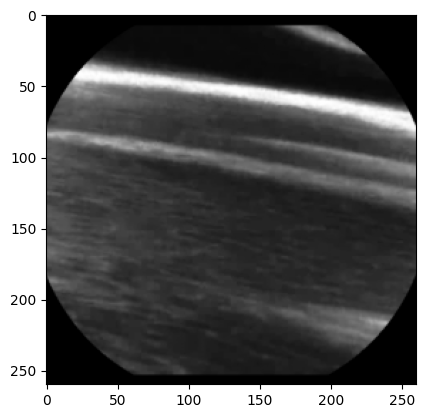

In [36]:
_ = plt.imshow(imagen, cmap='Greys_r' )

**Leer todas las imágenes y ponerlas en un solo archivo.**

In [38]:
%time img = datos['image_filename'].apply(lambda x: imread(ruta + x))   # recorre cada nombre de archivo del DataFrame Datos
                     # arma la ruta completa y lee la imagen
                     # img = Serie con una imagen (NumPy) por fila

CPU times: user 17.2 s, sys: 2.85 s, total: 20.1 s
Wall time: 37.4 s


In [ ]:
# Resultado: "img" es una Serie de pandas donde cada elemento es una imagen (arreglo NumPy).
#Todas las imágenes quedan cargadas en memoria RAM.

## Carga de imágenes con `skimage.io.imread`

**Tabla `datos` (original)** — contiene solo los nombres de archivo

| índice | image_filename |
|:---:|:---:|
| 0 | img_0001.png |
| 1 | img_0002.png |
| 2 | img_0003.png |
| ⋮ | ⋮ |
| 5061 | img_5062.png |
| 5062 | img_5063.png |

**Total:** 5,063 renglones

---

**Resultado `img`** — cada renglón contiene la imagen cargada como arreglo de NumPy

| índice | contenido (arreglo NumPy) | forma (shape) | tipo |
|:---:|:---|:---:|:---:|
| 0 | `[[ 12,  15,  18, ..., 201, 198, 195], ..., [ 40,  42,  45, ...,  88,  90,  91]]` | 260 × 260 | uint8 |
| 1 | `[[ 99, 101,  97, ..., 150, 148, 147], ..., [ 23,  25,  24, ...,  60,  62,  61]]` | 260 × 260 | uint8 |
| 2 | `[[210, 205, 198, ..., 180, 178, 176], ..., [ 55,  57,  58, ..., 110, 112, 113]]` | 260 × 260 | uint8 |
| ⋮ | ⋮ | ⋮ | ⋮ |
| 5062 | `[[ 70,  72,  71, ..., 130, 132, 133], ..., [ 15,  17,  16, ...,  45,  47,  46]]` | 260 × 260 | uint8 |

**Total:** 5,063 imágenes

---

**Relación entre ambas tablas** (comparten el mismo índice)

| índice | `datos['image_filename']` | `img` |
|:---:|:---:|:---:|
| 0 | img_0001.png | 🖼️ matriz 260 × 260 |
| 1 | img_0002.png | 🖼️ matriz 260 × 260 |
| 2 | img_0003.png | 🖼️ matriz 260 × 260 |
| ⋮ | ⋮ | ⋮ |
| 5062 | img_5063.png | 🖼️ matriz 260 × 260 |

---

**¿Qué hay dentro de una sola imagen?** (vista ampliada de `img[0]`)

| | col 0 | col 1 | col 2 | ... | col 259 |
|:---:|:---:|:---:|:---:|:---:|:---:|
| **fila 0** | 12 | 15 | 18 | ... | 195 |
| **fila 1** | 14 | 16 | 19 | ... | 193 |
| **fila 2** | 13 | 17 | 20 | ... | 190 |
| ... | ... | ... | ... | ... | ... |
| **fila 259** | 40 | 42 | 45 | ... | 91 |

- Cada celda es **un píxel**.
- Como las imágenes están en **escala de grises**, cada píxel es un solo número de **0 (negro)** a **255 (blanco)**.
- 260 × 260 = **67,600 píxeles por imagen**.
- En total: 5,063 × 67,600 ≈ **342 millones de valores** en memoria (≈ 342 MB en `uint8`).

<h2>Respaldamos el objeto img en un archivo pickle.<h2>

(si quieres conocer más sobre pickles de python, revisa [este enlace](https://programacion.net/articulo/los_pickles_de_python_1860))

In [42]:
# Guardar en archivo pickle
ruta2 = '/content/drive/MyDrive/TrackCienciaDeDatos/Data/PerceptronClasificadorCancerEsófago/' # directorio donde se guardará el
pickle.dump(img, open (ruta2 + "imagenes_numpy.pkl", 'wb'))

In [43]:
# Leer archivo pickle
ruta2 = '/content/drive/MyDrive/TrackCienciaDeDatos/Data/PerceptronClasificadorCancerEsófago/'
img = pickle.load(open(ruta2 + "imagenes_numpy.pkl", 'rb'))

In [68]:
img.info()

<class 'pandas.core.series.Series'>
RangeIndex: 5063 entries, 0 to 5062
Series name: image_filename
Non-Null Count  Dtype 
--------------  ----- 
5063 non-null   object
dtypes: object(1)
memory usage: 39.7+ KB


In [45]:
img[3555].shape

(260, 260)

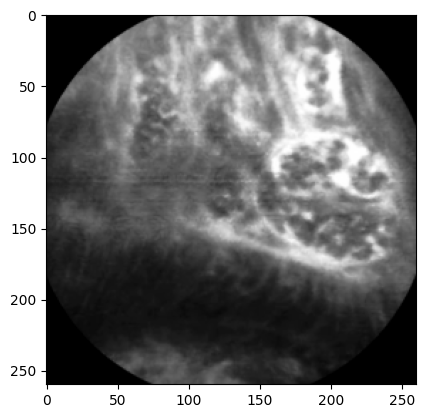

In [50]:
_ = plt.imshow(img[2015],  cmap='Greys_r')

- Dimensión 0: 260 renglones de pixeles de arriba a abajo
- Dimensión 1: 260 columnas de pixeles de izquierda a derecha


####  Transformar imágenes en vectores

In [47]:
# Una serie de pandas es también una secuencia (como lo son las listas,
# las tuplas, las cadenas de caracteres o los vectores de numpy).

print(type(img))

<class 'pandas.core.series.Series'>


In [48]:
# Cantidad de elementos en la serie
img.shape

(5063,)

In [49]:
# Cada elemento de mi secuencia es una matriz de 260 x 260
img[3673].shape

(260, 260)

## Apilar las imágenes en un solo arreglo con `np.stack`

`IMG = np.stack(img, axis=0)` junta las 5,063 imágenes de la Serie `img` en **un único arreglo de NumPy**.

- `np.stack` pone cada imagen de 260 × 260 una detrás de otra, como hojas de papel en una pila.
- `axis=0` indica que la nueva dimensión (el número de imagen) se crea **al principio**.

### Forma del resultado: `IMG.shape` → `(5063, 260, 260)`

| posición | significado | valor |
|:---:|:---|:---:|
| eje 0 | número de imagen | 5063 |
| eje 1 | alto (filas) | 260 |
| eje 2 | ancho (columnas) | 260 |

### Antes y después

| | Antes: Serie `img` | Después: arreglo `IMG` |
|:---|:---|:---|
| **Tipo** | Serie de pandas | Arreglo de NumPy |
| **Contenido** | 5,063 imágenes sueltas, una por renglón | Un solo bloque con todas las imágenes |
| **Forma** | `(5063,)` | `(5063, 260, 260)` |
| **Acceso a la primera imagen** | `img[0]` | `IMG[0]` |

### ¿Por qué se hace esto?

- Las librerías de Machine Learning (scikit-learn, TensorFlow, PyTorch) esperan los datos en **un solo arreglo** con la forma `(n_imágenes, alto, ancho)`, no en una Serie de pandas.
- Permite operar sobre todas las imágenes a la vez:
  - `IMG[0]` → primera imagen
  - `IMG[:100]` → primeras 100 imágenes
  - `IMG / 255` → normaliza todas las imágenes de un solo golpe

### Requisitos y precauciones

- **Todas las imágenes deben tener la misma forma** (260 × 260). Si una fuera distinta, `np.stack` daría error.
- **Se crea una copia de los datos**: en memoria quedan las imágenes dos veces (en `img` y en `IMG`), unos **342 MB** cada una.
- Si la memoria de Colab se aprieta, se puede liberar la Serie original con `del img`.

In [69]:
IMG = np.stack(img, axis=0)
IMG.shape

(5063, 260, 260)

## Aplanar las imágenes con `reshape`

`X = IMG.reshape(5063, 67600)` convierte cada imagen de 260 × 260 en **una sola fila de 67,600 píxeles** (260 × 260 = 67,600).

| | Antes: `IMG` | Después: `X` |
|:---|:---:|:---:|
| **Forma** | `(5063, 260, 260)` | `(5063, 67600)` |
| **Cada imagen es** | una matriz | una fila |

- Cada **renglón** es una imagen y cada **columna** es un píxel.
- No cambia ningún valor, solo reacomoda los números.
- Se hace porque los modelos de scikit-learn esperan una tabla de 2 dimensiones.

In [70]:
X = IMG.reshape(5063, 67600)
X.shape

(5063, 67600)

##### Visualizamos ejemplos de ambas clases de imagenes

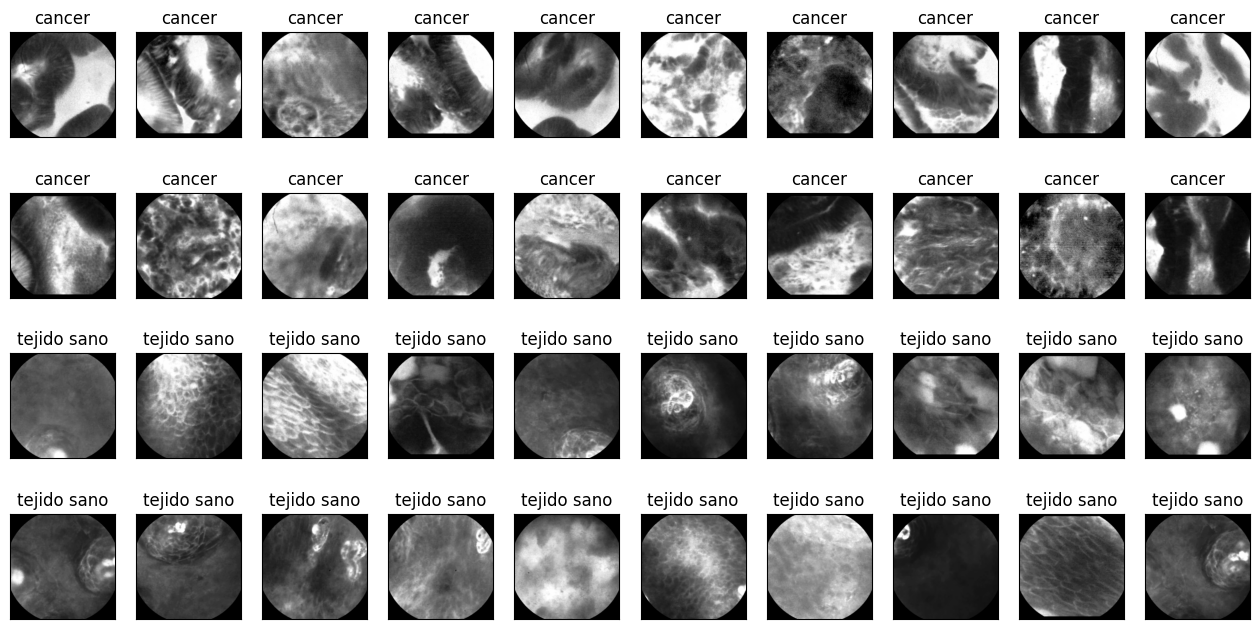

In [71]:
# Con el método GroupBy de Pandas separamos el data frame en dos, de acuerdo
# a nuestra etiqueta.
porClase = datos.groupby('class_number')

# Elijimos al azar n muestras de cada subconjunto y guardamos la posición de las
# imagenes cancerigenas en la lista "c" y en  "s" las de tejido sano.
n = 20
c = random.sample(porClase.get_group(1).index.tolist(), n)
s = random.sample(porClase.get_group(0).index.tolist(), n)


# Creamos el espacio para las 40 imagenes que vamos a desplegar
fig = plt.figure(figsize=(16, 8))
columns = 10
rows = 4

# Desplegamos las imagenes
for i in range(0, 40):
    fig.add_subplot( rows, columns, i+1)
    if i < 20:
        plt.imshow(img[c[i]],cmap='Greys_r')
        plt.title('cancer')
        plt.xticks([])
        plt.yticks([])
    else:
        plt.imshow(img[s[i-20]], cmap='Greys_r')
        plt.title('tejido sano')
        plt.xticks([])
        plt.yticks([])
plt.show()

## Paso 3. Construcción de nuestro clasificador

### 3.1  Crear subconjuntos de entrenamiento y prueba



In [72]:
# Manda el 30% al conjunto de test:
# Test: 1519
# Train: 3544

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    shuffle=True,  # Revuelve los datos antes de dividir. Es importante porque las imágenes suelen venir ordenadas
    stratify=y,     #mantiene la misma proporción de cada clase en ambos grupos. Si en total tienes 80% "ok" y 20% "defecto", tanto el grupo de entrenamiento como el de prueba tendrán ese 80/20.
                    #Es especialmente útil cuando una clase tiene pocas muestras, como suele pasar con los defectos.
    random_state=5  #fija la "semilla" del revuelto, para que cada vez que ejecutes la celda salga exactamente la misma división
)


In [73]:
# ¿Cómo son los conjuntos de entrenamiento y prueba?
print("Conjunto de Entrenamiento")
print(f"X: {X_train.shape}")
print(f"y: {y_train.shape}")
print(f"Proporción de imágenes cancerígenas: {y_train.mean():.3f}\n")

print("Conjunto de Prueba")
print(f"X: {X_test.shape}")
print(f"y: {y_test.shape}")
print(f"Proporción de imágenes cancerígenas: {y_test.mean():.3f}")

Conjunto de Entrenamiento
X: (3544, 67600)
y: (3544,)
Proporción de imágenes cancerígenas: 0.710

Conjunto de Prueba
X: (1519, 67600)
y: (1519,)
Proporción de imágenes cancerígenas: 0.710


### 3.2  Entrenamiento



In [74]:
model = Perceptron(max_iter=1000, random_state=0, verbose=False).fit(X_train, y_train)

print("Iterations: ", model.n_iter_)

Iterations:  57


## Perceptrón

`Perceptron(max_iter=1000, random_state=0).fit(X_train, y_train)` entrena un clasificador lineal: el modelo más simple de red neuronal.

**¿Cómo funciona?**
1. Cada píxel se multiplica por su **peso** (`w`).
2. Se suman todos los resultados y se agrega el **sesgo** (`b`).
3. Si el resultado es **mayor a 0** → clase 1; si no → clase 0.
4. Cada vez que se equivoca, ajusta los pesos. Repite hasta dejar de equivocarse o llegar a `max_iter`.

**Pesos y sesgo** (equivalentes a las betas de una regresión)

| atributo | contenido | forma |
|:---|:---|:---:|
| `model.coef_` | un peso por píxel | `(1, 67600)` |
| `model.intercept_` | el sesgo `b` | `(1,)` |

**El hiperplano**
- Los pesos y el sesgo juntos **son el hiperplano**: la frontera donde `w·x + b = 0`.
- Los pesos definen su orientación y el sesgo lo desplaza.
- En 2D es una línea, en 3D un plano, y en 67,600 dimensiones un hiperplano.
- De un lado queda una clase y del otro la otra.

**A tener en cuenta**
- Solo separa perfectamente si las clases son **linealmente separables**.
- `model.n_iter_` indica cuántas pasadas necesitó. Si llega a 1000, probablemente **no convergió**.

En 57 iteraciones logró encontrar la frontera donde w·x + b = 0

In [75]:
# Guardamos los coeficientes del modelo
betas = model.coef_
betas.shape

(1, 67600)

In [77]:
#Mostrando el sesgo Beta 0:

beta0 = model.intercept_
beta0

array([-720.])

In [ ]:
betas[0, 50310:50320]

array([-6260.,  4608., 14775., 19668., 14126., 10948.,  6639.,  3357.,
        3500.,  5002.])

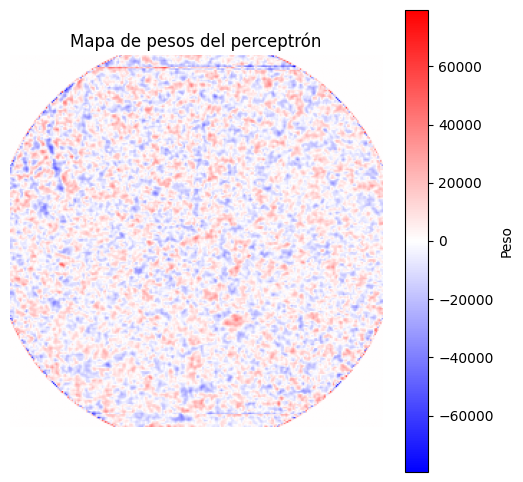

In [76]:
##Se toman todos los pesos y se convierten en imagen, para poder ver gráficamente qué pixeles,
#tienen un mayor peso que empujan hacia una clasificación 1 (tejido cancerigeno) y cuales a 0
#(tejido sano)

import numpy as np
import matplotlib.pyplot as plt

# Reacomodar los 67,600 pesos en una imagen de 260 x 260
pesos = model.coef_[0].reshape(260, 260)

# Límite simétrico para que el 0 quede en el centro de la escala de color
limite = np.abs(pesos).max()

plt.figure(figsize=(6, 6))
plt.imshow(pesos, cmap='bwr', vmin=-limite, vmax=limite)
plt.colorbar(label='Peso')
plt.title('Mapa de pesos del perceptrón')
plt.axis('off')
plt.show()

Para leer el mapa: las zonas rojas son píxeles con peso positivo, que empujan la decisión hacia la clase 1 cuando son brillantes; las azules tienen peso negativo y empujan hacia la clase 0; las blancas tienen peso cercano a cero, es decir, el modelo casi las ignora. Esas zonas blancas equivalen a lo que en inspección quedaría fuera de tu ROI.

### 3.3 Pedicción

In [78]:
y_predict = model.predict(X_test)  # Predice la etiqueta de cada imagen en X_test
y_predict[:20]

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1])

### 3.4 Evaluación

In [79]:
y_test.to_numpy()[:20]

array([1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1])

In [80]:
print(f"Exactitud: {(y_test == y_predict).mean():.4f}")

Exactitud: 0.9302


Además de evaluar el desempeño en el conjunto de prueba, es muy importante comparar el error en el entrenamiento contra el error de generalización.
Con estas dós métricas podemos darnos cuenta de si el modelo  está logrando aprender los patrones que presentan los datos y si es capaz de generalizar ese resultado.

In [83]:
# Es muy importante comparar el error en el entrenamiento contra el error de generalización
print(f"Exactitud conjunto entrenamiento: {model.score(X_train, y_train):.4f}")
print(f"Exactitud conjunto prueba: {model.score(X_test, y_test):.4f}")

Exactitud conjunto entrenamiento: 0.9901
Exactitud conjunto prueba: 0.9302


Mas allá de conocer qué tanto se equivoca el clasificador en imagenes nuevas, es importante distinguir la naturaleza de esos errores. Para ello nos servimos de la "Matriz de confusión"


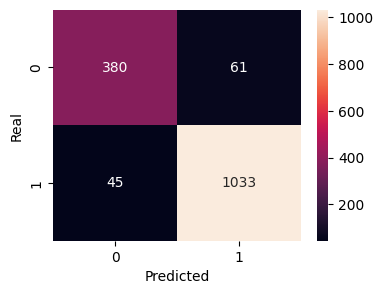

In [84]:
def matriz_confusion(y_test, y_predict):
    df = pd.DataFrame({
        'Real': y_test,
        'Predicted': y_predict
    })
    # Matriz de confusión
    confusion_matrix = pd.crosstab(df['Real'],df['Predicted']
                               )
    fig, ax = plt.subplots(figsize=(4, 3))  # Tamaño de la figura
    _ = sns.heatmap(confusion_matrix, annot=True, fmt='g',  ax=ax)

matriz_confusion(y_test, y_predict)

**Errores**:


61 Pruebas que eran tejido sano y que se clasifico como tejido cancerigeno


45 Pruebas que eran tejido cancerigeno y que se clasifico como tejido sano

## Paso 4. Entrenamiento de perceptron utilizando margen

In [ ]:
model_2 = Perceptron(max_iter=1000,  random_state=0, verbose=False,
                    penalty='l2', alpha=7e-9)
model_2.fit(X_train,y_train)

print("Exactitud conjunto entrenamiento: %.2f%%" % (model_2.score(  X_train, y_train)*100.0))
print("Exactitud conjunto prueba: %.2f%%" % (model_2.score(X_test, y_test)*100.0))

Exactitud conjunto entrenamiento: 98.65%
Exactitud conjunto prueba: 93.15%


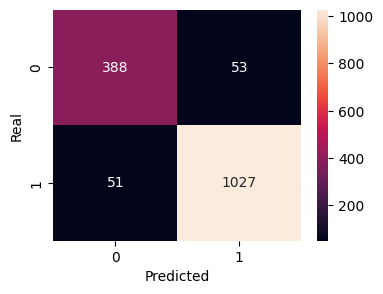

In [ ]:
y_predict_2 = model_2.predict(X_test)
matriz_confusion(y_test, y_predict_2)